### 自然言語処理

画像認識は、もともと画像データが多次元ベクトルとして、よく似た画像が近いベクトルで表現されるなど、機械学習で処理しやすい前提が整っている。

一方、自然言語などのテキストは、文字コードが近くても意味が近いわけではない。


自然言語を機械学習で処理するためには、テキストの特徴量を多次元ベクトルでうまく表現することが鍵になる。

### 携帯要素解析
言語における意味の基本単位は __語(word)__ 。

#### 英語と日本語
自然言語処理は、言語の種類によって難しさや扱い方が異なる。

- (英語文) I bought a book
- (日本語文) 私は本を買った

英語は、空白で区切られたものを語と考えることができる。
したがって、Python の標準文字列ライブラリだけで、簡単に語を取り出すことができる。

日本語では、まず語の区切りを判定する必要がある。

しかし、この語の区切りを判定するのがかなりの難処理となる。

そこで、専用のツール/ライブラリが必要。

### spaCy/GINZA

spaCy は、Explosion AI 社の開発するオープンソースの自然言語処理ライブラリ。
2019 年に、 リクルート AI 研究所と国立言語研究所の研究成果である GiNZA が登場し、実用的な日本語処理が手軽に利用できるようになった。



In [7]:
# 形態素解析による字句解析
import spacy

# spaCy / GiNZA のバージョン差異で compound_splitter の設定エラーが出る場合の回避
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])

doc = nlp("私は本を買った") #形態素解析


for word in doc:
    print(word.i, word.orth_, word.lemma_, word.pos_, word.tag_)


0 私 私 PRON 代名詞
1 は は ADP 助詞-係助詞
2 本 本 NOUN 名詞-普通名詞-一般
3 を を ADP 助詞-格助詞
4 買っ 買う VERB 動詞-一般
5 た た AUX 助動詞


In [8]:
# 日本語文を安吾単位に分割する関数を定義
import spacy

# spaCy / GiNZA のバージョン差異で compound_splitter の設定エラーが出る場合の回避
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])


def wakachi(s):
    doc = nlp(s)
    return [word.lemma_ for word in doc]  # word.lemma_ は標準形

print(wakachi('私は本を買った'))

['私', 'は', '本', 'を', '買う', 'た']


### 感想文の分析

In [1]:
# データの確認
import pandas as pd

df = pd.read_csv('./data/movie2024.csv')

df.head()

,映画タイトル,感想,評価,泣ける,笑える,勉強,キュキュン,怖い,ワクワク,ハラハラ
0,ウィッシュ,ディズニー100周年の集大成。2Dと3Dの融合で今までにない映像。,5,5,4,4,0,3,5,4
1,ダンジョンズ&ドラゴンズ,世界発のRPGが題材の作品。ユニークでおもしろい,4,3,4,1,3,2,5,5
2,鬼誕生 ゲゲゲの謎,なんとなく大人向けで怖くておもしろい,4,3,2,2,1,4,4,5
3,タイタニック,とても泣ける。純愛で感動した。,5,5,2,3,5,5,5,5
4,パリピ公明 アニメ総集編,懐かしの音楽が劇場音響で聞けて最高,3,1,3,1,1,1,5,2


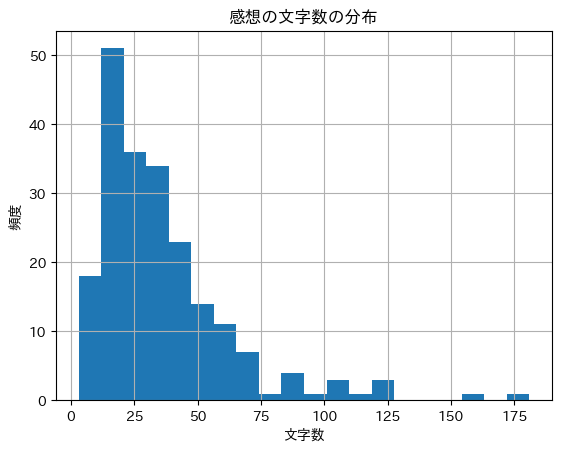

In [2]:
# 文字数をカウント

# データの確認
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

df = pd.read_csv('./data/movie2024.csv')

df["文字数"] = df["感想"].str.len() # 感想の文字数をカウントして新しい列「文字数」を作成

# 文字数の分布をヒストグラムで表示
plt.hist(df["文字数"], bins=20)
plt.grid()
plt.xlabel("文字数")
plt.ylabel("頻度")
plt.title("感想の文字数の分布")
plt.show()


### 単語レベルの解析
感想から単語を抽出して、どのような単語が使われているか調べてみる。

ここでは、形態素解析の品詞情報(`_pos`)から、動詞、形容詞、名詞だけに着目する。

>- *標準形変換* : 活用のある単語（例. 「買った」）は、買うのように標準形に変換する
>- *ストップワード除外* : 解析の精度を上げるために不要な記号や単語を取り除く


In [ ]:
# 単語を抽出
import spacy
import pandas as pd

df = pd.read_csv('./data/movie2024.csv')

# spaCy / GiNZA のバージョン差異で compound_splitter の設定エラーが出る場合の回避
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])

words = []
for text in df["感想"]: # 感想列のテキストを1行ずつ処理
    doc = nlp(text) # 形態素解析を実行して、単語のリストを取得
    for word in doc: # 単語ごとに処理
        # 動詞(VERB), 名詞(NOUN), 形容詞(ADJ)のみ抽出
        if word.pos_ == 'VERB' or word.pos_ == 'NOUN' or word.pos_ == 'ADJ':
            words.append(word.lemma_)  #標準形に変換してリストに追加
print(len(words))
print(words[:30]) #先頭30語だけ


1847
['周年', '集大成', 'd', 'd', '融合', '今まで', 'ない', '映像', '世界', '発', 'RPG', '題材', '作品', 'ユニーク', 'おもしろい', 'ない', '大人', '向け', '怖い', 'おもしろい', '泣ける', '純愛', '感動', '懐かしい', '音楽', '劇場', '音響', '聞ける', '最高', '世界観']


### 単語の頻出度と視覚化


1847
['周年', '集大成', 'd', 'd', '融合', '今まで', 'ない', '映像', '世界', '発', 'RPG', '題材', '作品', 'ユニーク', 'おもしろい', 'ない', '大人', '向け', '怖い', 'おもしろい', '泣ける', '純愛', '感動', '懐かしい', '音楽', '劇場', '音響', '聞ける', '最高', '世界観']


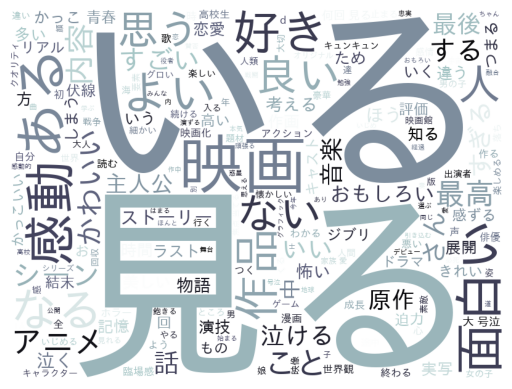

In [ ]:
# 既出単語を分析 ワードクラウドで視覚化
import spacy
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.font_manager as fm


df = pd.read_csv('./data/movie2024.csv')

# spaCy / GiNZA のバージョン差異で compound_splitter の設定エラーが出る場合の回避
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])

words = []
for text in df["感想"]:
    doc = nlp(text)
    for word in doc:
        # 動詞(VERB), 名詞(NOUN), 形容詞(ADJ)のみ抽出
        if word.pos_ == 'VERB' or word.pos_ == 'NOUN' or word.pos_ == 'ADJ':
            words.append(word.lemma_)  #標準形に変換する
print(len(words))
print(words[:30]) #先頭30語だけ


pd.DataFrame({"words":words}).value_counts() # 単語の頻度をカウント


word_chain = ' '.join(words) # 単語のリストをスペース区切りの文字列に変換

# japanize_matplotlibが使用しているフォントの絶対パスを取得
fpath = fm.findfont(fm.FontProperties(family="IPAexGothic"))

model = WordCloud(width=800, height=600, background_color='white', colormap='bone', font_path=fpath) # WordCloudオブジェクトを作成
W = model.generate(' '.join(words)) # 単語のリストをスペース区切りの文字列に変換して、ワードクラウドを生成

plt.imshow(W) # ワードクラウドを画像として表示
plt.axis('off') # 軸を非表示にする
plt.show() # ワードクラウドを表示




In [22]:
# 既出単語を分析 ワードクラウドで視覚化
import spacy
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.font_manager as fm
import numpy as np


df = pd.read_csv('./data/movie2024.csv')

# --- ここでデータをクレンジング ---
# 全角数字を半角に変換し、数値型へ
df["評価"] = pd.to_numeric( 
    df["評価"].astype(str).str.translate(str.maketrans('０１２３４５６７８９', '0123456789')), # 全角数字を半角に変換
    errors='coerce' # 数値に変換できないものはNaNにする
)
df = df.dropna(subset=['評価', '感想']) # 評価や感想が空の行を除外
# ------------------------------


# spaCy / GiNZA のバージョン差異で compound_splitter の設定エラーが出る場合の回避
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"]) # 形態素解析のモデルをロード


words = []
scores = []

for text, score in zip(df["感想"], df["評価"]): # 感想列のテキストと評価列の数値を同時に処理
    doc = nlp(text) # 形態素解析を実行して、単語のリストを取得
    for word in doc: # 単語ごとに処理
         # 動詞(VERB), 名詞(NOUN), 形容詞(ADJ)のみ抽出
        if word.pos_ in ['VERB', 'NOUN', 'ADJ']:
            words.append(word.lemma_) #標準形に変換してリストに追加
            scores.append(score) # 単語に対応する評価をリストに追加
print(words[:30]) #
print(scores[:30])

print()

keyword = pd.DataFrame({'キーワード': words, '評価': scores, '出現数': [1]*len(words)}) # キーワード、評価、出現数のデータフレームを作成

# キーワードごとに評価の平均と出現数の合計を計算し、出現数でソート
result = keyword.groupby('キーワード').agg({'評価': 'mean', '出現数': 'sum'}).sort_values(by='出現数')

print(result)




['周年', '集大成', 'd', 'd', '融合', '今まで', 'ない', '映像', '世界', '発', 'RPG', '題材', '作品', 'ユニーク', 'おもしろい', 'ない', '大人', '向け', '怖い', 'おもしろい', '泣ける', '純愛', '感動', '懐かしい', '音楽', '劇場', '音響', '聞ける', '最高', '世界観']
[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 5.0, 5.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]

             評価  出現数
キーワード               
鳥肌     5.000000    1
場合     5.000000    1
報告     5.000000    1
埋まる    1.000000    1
綺麗     5.000000    1
...         ...  ...
感動     4.840000   25
ある     4.250000   28
映画     4.243243   37
いる     4.022727   44
見る     4.104167   48

[805 rows x 2 columns]


>__極性辞書とセンティメント解析__
>
>極性辞書は、ある単語が一般的にネガティブなのか、ポジティブなのかを、-1（ネガティブ）から1（ポジティブ）までのスコアの形で表現したもの。
>
>- 日本語評価極性辞書：東北大の乾・岡崎研究室が公開
>- 単語感情極性対応表：東工大の高村教授が公開
>
>センティメント分析などに便利。

### テキストのベクトル化

意味や内容が似ているテキストや単語が近くなるようにベクトル化する。 

もともと、類似文章検索 として研究されてきました技術。

In [26]:
import spacy
import pandas as pd

df = pd.read_csv('./data/movie2024.csv')

# spaCy / GiNZA のバージョン差異で compound_splitter の設定エラーが出る場合の回避
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])

def wakachi(s):
    doc = nlp(s)
    return [word.lemma_ for word in doc]  # word.lemma_ は標準形


# わかち書きの列を追加
df['わかち書き'] = df['感想'].map(lambda x: ' '.join(wakachi(x)))
df.head()


# csvファイルに保存
df.to_csv('./data/movie2024_wakachi.csv', index=False)

### BOWを使ってベクトル化

__BOW(Bag of Words)__ は最も古典的な文書の特徴量を捉えてベクトル化する手法。

- 出現する単語の個数をNとすると、それぞれのコメントは「どの単語が含まれているか」を1と0で並べた、**$N$ 次元のベクトル**として表現される。
- 文章の構造は全て無視し、「どの単語が含まれているか」だけに注目する。
- 文をベクトルで表現できれば、コサイン類似度 (cosine similarity) を用いて、類似度を求めることができる。

BOW は、`sklearn`モジュールの`CountVectorizer`を使って、求めることができる。

>sklearn は、英語圏で開発されたライブラリであり、入力文は英単語のように空白で区切られているという前提の為、
>
>日本語は「わかち書き」のように前処理しておく必要がある。

In [51]:
### ベクトルを得る

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

df = pd.read_csv('./data/movie2024_wakachi.csv')


docs = np.array(df['わかち書き'])
model = CountVectorizer()
bags = model.fit_transform(docs)

print(bags.toarray())

pd.DataFrame(bags.toarray(), columns=model.get_feature_names_out(), index=df['感想'])



[[0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


,10,100,1人,1人1人,20,2000,21,ai,big,bl,...,食べ物,飽きる,高い,高所,高校,高校生,高橋,魔法,鳥肌,黒柳
感想,,,,,,,,,,,,,,,,,,,,,
ディズニー100周年の集大成。2Dと3Dの融合で今までにない映像。,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
世界発のRPGが題材の作品。ユニークでおもしろい,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
なんとなく大人向けで怖くておもしろい,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
とても泣ける。純愛で感動した。,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
懐かしの音楽が劇場音響で聞けて最高,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
高橋恭平、顔がいい 畑芽育ちゃんかわいい,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
めちゃくちゃ泣いた。記憶をなくしていってしまう話。,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
丈くんが最近泣いたって言ってたから見た,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### コサイン類似度
コサイン類似度は、文書ベクトルの類似度を測る尺度としてよく使われる。

 ベクトルの向きがどの程度同じ方向を向いているか？という指標で、−1〜1の範囲をとる。

コサイン類似度を数式で記述すると以下のようになる。

$$ cos(x,y) = \frac{x ⋅ y}{|x| ⋅ |y|} = \frac{ \sum_{i=1}^{|V|} x_iy_i }{ \sqrt{\sum_{i=1}^{|V|} {x_i}^2 } ⋅ \sqrt{\sum_{i=1}^{|V|} {y_i}^2 } } $$


In [ ]:
# numPyにてコサイン類似度計算を実装

import numpy as np

def cosine_similarity(x, y):
    return np.dot(x, y)/(np.sqrt(np.dot(x, x))*np.sqrt(np.dot(y, y)))

X = np.array([0.7, 0.5, 0.3,0.1])
Y = np.array([0.8, 0.5, 0.2, 0.222])


print(cosine_similarity(X, Y))

0.9837126278799047


In [ ]:
# sklearnモジュールを使用してコサイン類似度を計算
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

X = np.array([[0.7,0.5,0.3,0.1], [0.1,0.2,0.9,0.9]])
Y = np.array([[0.8, 0.5, 0.2, 0.2], [0.1,0.2,0.9,0.9]])


print(cosine_similarity(X, Y))



[[0.98597181 0.44748449]
 [0.42427716 1.        ]]


In [62]:
# 類似コメント検索

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer


df = pd.read_csv('./data/movie2024_wakachi.csv')


docs = np.array(df['わかち書き'])
model = CountVectorizer()
bags = model.fit_transform(docs)

# print(bags.toarray())

# pd.DataFrame(bags.toarray(), columns=model.get_feature_names_out(), index=df['感想'])

def cosine_similarity(x, y):
    # x は基準となる1行 (1, N)
    # y は比較対象の全行 (M, N)
    # 分子：ドット積を計算（yを転置させて計算）
    num = np.dot(x, y.T)
    # 分母：それぞれのベクトルのノルム（大きさ）を計算
    det = np.linalg.norm(x) * np.linalg.norm(y, axis=1)
    return num / det

def print_sim(index):
    vec = bags.toarray()
    similarity = cosine_similarity(vec[index:index+1], vec)[0]
    top10 = np.argsort(similarity)[::-1][:10]
    for i in top10:
        print(i, similarity[i], df['映画タイトル'][i], df['感想'][i])


# 特定のコメントと類似度の高いコメントを表示
idx=113

print('類似度検索対象: [映画タイトル]',df['映画タイトル'][idx],', [感想]', df['感想'][idx],'\n')

print_sim(idx)


類似度検索対象: [映画タイトル] チアダン , [感想] おもしろい。すごい。広瀬すずがかわいい。 

113 0.9999999999999998 チアダン おもしろい。すごい。広瀬すずがかわいい。
15 0.6324555320336759 ホームアローン おもしろい。かわいい。
106 0.33806170189140655 キャラクター 深瀬さんが奇妙で最高に怖かった。でもすごくおもしろかった。
43 0.31622776601683794 ローマの休日 すごく感動した。白黒だけど良い。オードリーヘップバーンかわいい
174 0.31622776601683794 君たちはどう生きるか わらわらかわいい
140 0.2581988897471611 ピーチガール 山本美月がかわいかった
9 0.2581988897471611 ハウ 声の出ない犬がかわいい
123 0.22360679774997896 Gメン ただおもしろい学園もの
30 0.19999999999999996 キングダム 臨場感がすごい。続編が楽しみすぎる。
11 0.19999999999999996 胸が鳴るのは君のせい 青春映画ですごくキュンキュンした。


### TF-IDF
>BOWは、単語の出現を見るだけで、重要度を考慮に入れていない。

__TF-IDF(Term Frequency-Inverse Document Freequency: 単語頻度-逆文書頻度)__ :
- 一般的な単語と特徴のある重要な単語の区別をつける指標。

__単語 w が n 回現われるとき、TF(Term Frequence)__
$$ TF = \frac{n}{N} $$
__単語 w を含む文が d 個あるとき、IDF(Inverse Document Frequency)__
$$ IDF = - log \frac{d}{D} = log \frac{D}{d} $$
TF-IDFは、__TF__ と __IDF__ の積によって求まる。
$$ TF-IDF = \frac{n}{N} log \frac{D}{d} $$
IDF は一種の一般語フィルタとして働き、多くの文書に出現する語(一般的な語)は重要度が下がり、特定の文書にしか出現しない単語の重要度を上げる役割を果たす。

TF-IDF を用いることで、重要度の重みつけされたベクトルが得られる。

In [74]:
# TF-IDFを使用

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer  # tf-idf
import numpy as np


df = pd.read_csv('./data/movie2024_wakachi.csv')

# TF-IDFを使用してベクトル化
vectorizer = TfidfVectorizer(max_df=0.9) #文書全体の90%以上で出現する単語は無視する
X = vectorizer.fit_transform(df['わかち書き']) # ベクトル化
print('feature_names:', vectorizer.get_feature_names_out()) # ベクトル化された特徴量の名前を表示
print('X:')
print(X.toarray()) # ベクトル化された特徴量の値を表示


# 類似コメントの検索

# numPyにてコサイン類似度計算を実装
def cosine_similarity(x, y):
    # x は基準となる1行 (1, N)
    # y は比較対象の全行 (M, N)
    # 分子：ドット積を計算（yを転置させて計算）
    num = np.dot(x, y.T)
    # 分母：それぞれのベクトルのノルム（大きさ）を計算
    det = np.linalg.norm(x) * np.linalg.norm(y, axis=1)
    return num / det

# TF-IDFを使用して類似コメント検索
def print_sim_tf_idf(index):
    vec = X.toarray()
    similarity = cosine_similarity(vec[index:index+1], vec)[0]
    top10 = np.argsort(similarity)[::-1][:10]
    for i in top10:
        print(i, similarity[i], df['映画タイトル'][i], df['感想'][i])


# 特定のコメントと類似度の高いコメントを表示
idx=113

print('類似度検索対象: [映画タイトル]',df['映画タイトル'][idx],', [感想]', df['感想'][idx],'\n')

print_sim_tf_idf(idx)




feature_names: ['10' '100' '1人' '1人1人' '20' '2000' '21' 'ai' 'big' 'bl' 'cg' 'dx'
 'dximax' 'free' 'love' 'man' 'pr' 'rpg' 'sao' 'seed' 'snow' 'あう' 'あっ'
 'あと' 'あまり' 'あり' 'ありがと' 'ありきたり' 'ある' 'いい' 'いう' 'いえる' 'いく' 'いける' 'いしい'
 'いじめ' 'いじめる' 'いつ' 'いまいち' 'いまだ' 'いる' 'いろいろ' 'うたう' 'うち' 'うまい' 'えぐい' 'える'
 'えんぴつ' 'おいしい' 'おこがましい' 'おすすめ' 'おもしろい' 'おもろい' 'おる' 'お菓子' 'かかわる' 'かける'
 'かっこ' 'かっこいい' 'かなり' 'から' 'かわいい' 'きっかけ' 'きる' 'きれい' 'くださる' 'くだる' 'くみ取れる'
 'くらい' 'くる' 'くん' 'ぐらい' 'けど' 'こだわり' 'こと' 'ことん' 'この' 'これ' 'こんな' 'ごろ' 'さすが'
 'させる' 'さらに' 'さる' 'さん' 'しか' 'しっかり' 'しまう' 'しんかい' 'じい' 'じっ' 'すき' 'すぎる' 'すく'
 'すごい' 'すすめる' 'すず' 'すべて' 'する' 'ずっと' 'せい' 'せる' 'せんせー' 'ぜひ' 'そう' 'そこそこ'
 'そなた' 'その' 'そもそも' 'それ' 'たい' 'たくさん' 'ただ' 'たち' 'たつ' 'たのしめる' 'たまに' 'たまる'
 'ため' 'たり' 'だいたい' 'だけ' 'ちゃう' 'ちゃん' 'ちゃんと' 'ちょっと' 'って' 'っぽい' 'つく' 'つつ'
 'つながり' 'つながる' 'つまる' 'つらい' 'てる' 'できる' 'です' 'でる' 'とき' 'ところ' 'とても' 'とにかく'
 'とも' 'とる' 'ない' 'なおす' 'ながら' 'なくす' 'なし' 'など' 'なに' 'なり' 'なる' 'なれる' 'なん'
 'のびる' 'のび太' 'はなし' 'はまる' 'はるか' 'ばかり' 'ひたすら' 'ひと' 'びっくり' 'ぶり' 'べ

### LSA（潜在的意味解析）
- トピックという文書と単語の間に存在する抽象的な概念を導入
- 各文書の BOW あるいは TF-IDF ベクトルを行とする文書数×単語数の行列を特異値分解（SVD)し、文書数×トピック数に次元削減。

In [ ]:
# LSAを使用して8次元に削減

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer  # tf-idf
import numpy as np
from sklearn.decomposition import TruncatedSVD # LSA


df = pd.read_csv('./data/movie2024_wakachi.csv')

# TF-IDFを使用してベクトル化
vectorizer = TfidfVectorizer(max_df=0.9) #文書全体の90%以上で出現する単語は無視する
X = vectorizer.fit_transform(df['わかち書き']) # ベクトル化



np.set_printoptions(suppress=True) # 小数点以下の表示を抑制
# SVD
svd = TruncatedSVD(n_components=8, n_iter=7, random_state=0) # n_componentsは削減後の次元数、n_iterは反復回数、random_stateは乱数シード
svd.fit(X.toarray()) # ベクトル化された特徴量を8次元に削減
X = svd.transform(X.toarray()) # ベクトル化された特徴量を8次元に削減したものをXに代入

def print_sim(index):
    vec = X
    similarity = cosine_similarity(vec[index:index+1], vec)[0] # コサイン類似度を計算
    top10 = np.argsort(similarity)[::-1][:10] # 類似度の高い順にインデックスを取得し、上位10件を選択
    for i in top10:
        print(i, similarity[i], df['映画タイトル'][i], df['感想'][i]) # 類似度、映画タイトル、感想を表示


# 特定のコメントと類似度の高いコメントを表示
idx=113

print('\n類似度検索対象: [映画タイトル]',df['映画タイトル'][idx],', [感想]', df['感想'][idx],'\n')

print_sim(idx)

pd.DataFrame(X,index=df['感想'])


# 徳一分解とは、行列を特異値分解（SVD）することで、元の行列を近似する方法です。
# 特異値分解は、任意の行列を3つの行列の積に分解する方法であり、これらの行列は元の行列の構造を表現します。
# 特異値分解を使用して、元の行列を近似することができます。
# これにより、元の行列の次元を削減し、データの特徴を抽出することができます。


類似度検索対象: [映画タイトル] チアダン , [感想] おもしろい。すごい。広瀬すずがかわいい。 

113 1.0000000000000002 チアダン おもしろい。すごい。広瀬すずがかわいい。
140 0.9940282269192949 ピーチガール 山本美月がかわいかった
174 0.9938740924414184 君たちはどう生きるか わらわらかわいい
15 0.9926436462433188 ホームアローン おもしろい。かわいい。
163 0.9881514914816363 シュガーラッシュ ゲームの中のお話で、色の使い方がポップでかわいかった。助け合うメインキャラクター達素敵
204 0.9742594148111366 なのに、千輝くんが甘すぎる 高橋恭平、顔がいい　畑芽育ちゃんかわいい
123 0.9670986927529178 Gメン ただおもしろい学園もの
106 0.9600482584344835 キャラクター 深瀬さんが奇妙で最高に怖かった。でもすごくおもしろかった。
1 0.8785412708193343 ダンジョンズ&ドラゴンズ 世界発のRPGが題材の作品。ユニークでおもしろい
9 0.8498759984144121 ハウ 声の出ない犬がかわいい


,0,1,2,3,4,5,6,7
感想,,,,,,,,
ディズニー100周年の集大成。2Dと3Dの融合で今までにない映像。,0.071408,0.092139,-0.036021,-0.013211,-0.043493,-0.024735,0.090449,-0.007074
世界発のRPGが題材の作品。ユニークでおもしろい,0.070299,0.028766,-0.067930,0.150971,-0.101081,0.128799,-0.012393,-0.095836
なんとなく大人向けで怖くておもしろい,0.107551,0.146216,-0.031412,0.197672,-0.141688,0.090615,-0.029761,-0.080985
とても泣ける。純愛で感動した。,0.322300,-0.397619,0.134410,-0.003099,-0.024965,0.043535,0.268167,0.281828
懐かしの音楽が劇場音響で聞けて最高,0.058591,0.006129,-0.060176,-0.096966,0.064417,0.244195,-0.085025,0.053578
...,...,...,...,...,...,...,...,...
高橋恭平、顔がいい 畑芽育ちゃんかわいい,0.054424,0.022228,0.073669,0.241121,-0.083123,0.207624,-0.027358,-0.067912
めちゃくちゃ泣いた。記憶をなくしていってしまう話。,0.070155,-0.041425,0.017281,-0.024668,0.078291,-0.072401,-0.090970,-0.022887
丈くんが最近泣いたって言ってたから見た,0.130674,-0.009949,-0.188589,0.073869,0.130308,-0.061583,-0.031813,-0.074822


### 単語分散表現
- 単語分散表現（単語ベクトル）とは、最後に単語の持つ意味的な情報を用いる手法
- 単語を多次元空間上の座標にマッピングすることで、単語同士の類似度を比較したり、加減算したりすることができるようになる。
- 単語分散表現を求める方法として、2013年にGoogle研究所が発表したWord2Vecが有名。
    - 「同じ文脈で登場する単語は似た意味を持つ」という分布仮説をベースにして、ニューラルネットワークで計算される。

#### 単語ベクトル
GiNZAは、形態素解析したときに単語ベクトルが`voctor`プロパティで付与されている。



In [ ]:
# 単語ベクトルの確認

import spacy

nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])


doc = nlp('スポーツ 良い')
print(doc[0].vector.shape, doc[0].vector) # 「スポーツ」の単語ベクトル
# print(doc[1].vector.shape, doc[1].vector) # 「良い」の単語ベクトル

(300,) [ 0.13375778 -0.17257443  0.02516939  0.1324365  -0.05213964  0.36968458
 -0.40936273  0.11759301 -0.01370322  0.16887937  0.25840095 -0.03895048
 -0.12300318 -0.16547137  0.14446233 -0.04904341 -0.38537306  0.2110346
 -0.22277047 -0.06400058 -0.21376547  0.0176675  -0.00410596 -0.01469426
 -0.02343989 -0.11121087  0.23225866  0.03399521  0.0003097  -0.17104886
 -0.05210022  0.04949599  0.24797468  0.25802103 -0.12333041  0.31917045
  0.17388728  0.2035169   0.06582559 -0.25228208  0.18981704  0.15296002
 -0.3062748  -0.13662805 -0.25415638  0.14236008  0.116825    0.00469154
 -0.05889941  0.07863956  0.4675573   0.06081422  0.2529209  -0.07001508
  0.34606618  0.2717276   0.25792852 -0.2984004  -0.07375812 -0.09873105
  0.14780869  0.0873313   0.10026332 -0.10008292 -0.3316018  -0.02629723
  0.5940275   0.30866838 -0.08813549 -0.32104307  0.03274322  0.10554635
 -0.30488187  0.377073   -0.0811692   0.20839754  0.38205898  0.02628802
  0.18617581  0.19931976  0.00599956  0.06431

### 文章ベクトル
- 文章ベクトルは、単語ベクトルから算出される。
- GiNZAでは、各単語の平均値ベクトルとして算出される。

In [88]:
# 文章ベクトルの確認

import spacy

nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])


doc = nlp('ポーツできる場所があるのが良い')
print(doc.vector.shape, doc.vector) # 単語ベクトル

(300,) [-0.02920693 -0.05320758 -0.0522105  -0.08731095 -0.03517435 -0.02590578
  0.00206362 -0.1063849  -0.09927486 -0.04500962  0.04499383 -0.06481141
 -0.0288375   0.04145418 -0.11855906 -0.13537505 -0.07372829 -0.005988
 -0.1166847   0.00200363 -0.07982864  0.0653679  -0.02242133  0.03441318
 -0.09967872 -0.10132443 -0.17745972 -0.00701735 -0.01890183 -0.02232861
  0.00425247 -0.09943429  0.1189977   0.11469252 -0.01476635 -0.00565097
 -0.08678276  0.08944558 -0.06026531  0.01860928  0.07967254  0.03719408
 -0.0694015  -0.03305633 -0.04918492 -0.06143166 -0.00042069  0.01650344
 -0.12821096  0.01242355 -0.01574672  0.02855304 -0.01309349  0.06785982
  0.02561383  0.0167272  -0.02429795 -0.01248624 -0.05111359 -0.00523373
 -0.03138427  0.03268416  0.03163368  0.00560306  0.00034257 -0.06571576
  0.12110818  0.18030974  0.10791279  0.01394656  0.0255538   0.07066533
  0.013614    0.06444446 -0.05641092  0.04407748  0.03320919  0.0004552
  0.02246881 -0.01736393 -0.07054626 -0.0744301

In [ ]:
# ginzaで文章ベクトルを算出し、類似度を計算

import spacy
import numpy as np
import pandas as pd
# 1. モデルのロードとデータの読み込み
# compound_splitterを外すことで動作を安定させています
nlp = spacy.load("ja_ginza", exclude=["compound_splitter"])
df = pd.read_csv('./data/movie2024_wakachi.csv')

# 2. 類似度計算関数の定義
def cosine_similarity(x, y):
    """
    x: 基準ベクトルの2次元配列 (1, N)
    y: 比較対象ベクトルの2次元配列 (M, N)
    """
    # 分子：ドット積
    num = np.dot(x, y.T)
    # 分母：ノルムの積（ゼロ除算を防ぐために微小値を加算）
    det = np.linalg.norm(x) * np.linalg.norm(y, axis=1)
    return num / (det + 1e-9)

# 3. 全文章のベクトル化（事前に一括計算）
print("全文章のベクトルを算出中...")
# 各文章の平均ベクトルを取得して行列化
all_vectors = np.array([nlp(str(text)).vector for text in df['わかち書き']])

# 4. 検索関数の定義
def print_sim(index, vec_data):
    """
    index: 検索対象の行番号
    vec_data: 事前に計算した全文章のベクトル行列
    """
    # 類似度計算
    similarity = cosine_similarity(vec_data[index:index+1], vec_data)[0]
    # NaNが発生していた場合に備えて0で置換
    similarity = np.nan_to_num(similarity)
    # 類似度が高い順にソート（自分自身も含む）
    # [::-1]で降順にし、上位10件を抽出
    top10 = np.argsort(similarity)[::-1][:10]
    print(f"--- '{df['映画タイトル'][index]}' に似た感想の検索結果 ---")
    for i in top10:
        # スコア、タイトル、感想（先頭40文字）を表示
        score = similarity[i]
        title = df['映画タイトル'][i]
        review = str(df['感想'][i]).replace('\n', ' ')[:40]
        print(f"{i:3d} | 類似度: {score:.3f} | {title} | {review}...")

# 5. 実行
idx = 113

# インデックス範囲外エラーを防ぐチェック
if idx < len(df):
    print_sim(idx, all_vectors)
else:
    print(f"エラー: インデックス {idx} はデータ範囲外です。")

全文章のベクトルを算出中...（これには数秒かかります）
--- 'チアダン' に似た感想の検索結果 ---
113 | 類似度: 1.000 | チアダン | おもしろい。すごい。広瀬すずがかわいい。...
 15 | 類似度: 0.844 | ホームアローン | おもしろい。かわいい。...
106 | 類似度: 0.807 | キャラクター | 深瀬さんが奇妙で最高に怖かった。でもすごくおもしろかった。...
185 | 類似度: 0.801 | バイオハザードⅢ | ミラ・ジョヴォヴィッチがほんとにかっこいい。ハラハラドキドキです。...
124 | 類似度: 0.786 | バケモノの子 | 細田守の作品。ストーリーがとても良かった。感動しました。...
 98 | 類似度: 0.785 | 竜とそばかすの姫 | 面白くない。眠くなる。歌は良かった。...
  8 | 類似度: 0.781 | 名探偵コナン　黒鉄の魚影 | とても面白くて何回でも見たい。哀ちゃんがとにかくかわいい。...
191 | 類似度: 0.776 | スターウォーズ | おもろい。曲がいい。海外の俳優さんかっこいい。...
186 | 類似度: 0.760 | PとJK | 何も面白くない。亀梨君がかっこよかった。...
 95 | 類似度: 0.758 | 純と愛（朝ドラ） | はなしがつまらなかった。起承転結すべてが中途半端だった。...


>現在の自然言語処理では、TransformerによるBERTと呼ばれる文脈を含んだベクトル化が発明され、
>
>人工知能や機械翻訳の精度が大きく向上している。
